In [1]:
import torch
import torch.nn as nn 
import torch.optim as optim 
from torch.utils.data import DataLoader, TensorDataset,random_split
import numpy as np
import random 
import matplotlib.pyplot as plt

In [2]:
X=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
Y=np.array([-2.0,-1.0,0.0,1.0,2.0,3.0,4.0], dtype=np.float32)
np.random.seed(0)
a=np.random.rand( ) # 1.初始化参数
b=np.random.rand( )
print(f"Initial parameters: a={a}, b={b}")
lr=0.01 #学习率
n= len(X) #总量
for epoch in range(100):
    # 2.前向传播
    Y_pred=a*X+b
    # 3.计算损失
    loss=np.mean((Y_pred-Y)**2)
    # 4.反向传播
    grad_a=np.mean(2*(Y_pred-Y)*X)
    grad_b=np.mean(2*(Y_pred-Y))
    # 5.更新参数
    a -= lr * grad_a
    b -= lr * grad_b
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss}, Parameters: a={a}, b={b}")
# 6.预测
X_test=5.0
Y_test=a*X_test+b
print(f"真实值：{X_test}")
print(f"预测值：{Y_test}")

Initial parameters: a=0.5488135039273248, b=0.7151893663724195
Epoch 0, Loss: 0.8839744925498962, Parameters: a=0.5796284079551697, b=0.7099092602729797
Epoch 10, Loss: 0.4023558795452118, Parameters: a=0.7656778693199158, b=0.6383657455444336
Epoch 20, Loss: 0.26865023374557495, Parameters: a=0.8408185243606567, b=0.557116687297821
Epoch 30, Loss: 0.1944865733385086, Parameters: a=0.8773294687271118, b=0.48087382316589355
Epoch 40, Loss: 0.14261679351329803, Parameters: a=0.8993982672691345, b=0.41333121061325073
Epoch 50, Loss: 0.10478301346302032, Parameters: a=0.9152637720108032, b=0.35470589995384216
Epoch 60, Loss: 0.07700802385807037, Parameters: a=0.9278549551963806, b=0.3042077422142029
Epoch 70, Loss: 0.05659785494208336, Parameters: a=0.9383151531219482, b=0.26083678007125854
Epoch 80, Loss: 0.04159743711352348, Parameters: a=0.9471721649169922, b=0.22362865507602692
Epoch 90, Loss: 0.0305726807564497, Parameters: a=0.9547287225723267, b=0.19172142446041107
真实值：5.0
预测值：4.969

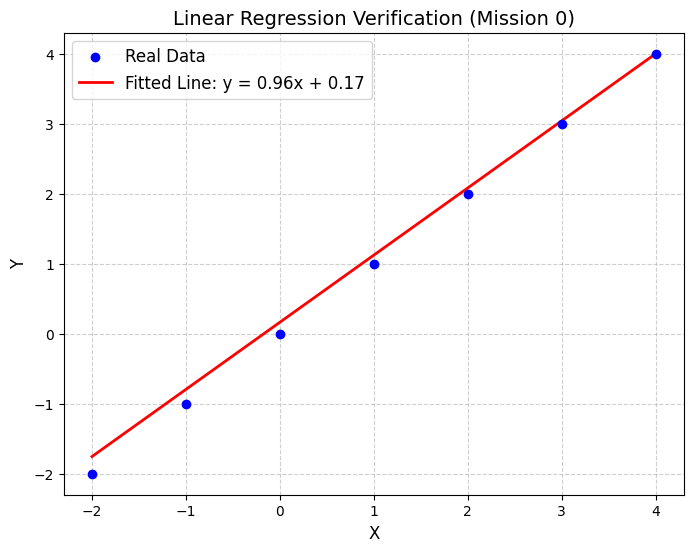

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='blue', label='Real Data', zorder=5)
Y_fitted = a * X + b 
plt.plot(X, Y_fitted, color='red', linewidth=2, label=f'Fitted Line: y = {a:.2f}x + {b:.2f}')
plt.title('Linear Regression Verification (Mission 0)', fontsize=14)
plt.xlabel('X', fontsize=12)
plt.ylabel('Y', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.show()

在pytorch中，通常是直接使用包装好的函数，如loss.backward()用来直接计算梯度，同时，由于loss.backward()有累加效应，需要进行梯度归零
此时代码体现为
```py
loss.backward()
    with torch.no_grad(): #不影响自动微分模块
        a -= learning_rate * a.grad
        b -= learning_rate * b.grad
        a.grad.zero_()
        b.grad.zero_()
```

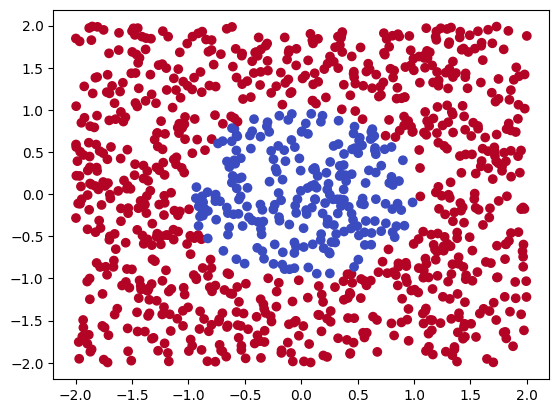

初始数据形状为: (10000, 3)


In [4]:
# utils/createDataAndPlot.py中的内容

NUM_OF_DATA = 10000


def tag_entry_circle(x, y):
    if x**2 + y**2 < 1:
        tag = 0
    else:
        tag = 1
    return tag


def tag_entry_triangle(x, y):
    x = x + 1
    y = y + 1
    if (
        (0 <= x <= 1.5)
        and (0 <= y <= 2)
        and (y >= (2 / 1.5) * x and y >= -(2 / 1.5) * (x - 1.5))
    ):
        tag = 0
    else:
        tag = 1
    return tag


def tag_entry_square(x, y):
    x = x + 1
    y = y + 1
    if (0 <= x <= 2) and (0 <= y <= 2):
        tag = 0
    else:
        tag = 1
    return tag


function = {
    "circle": tag_entry_circle,
    "triangle": tag_entry_triangle,
    "square": tag_entry_square,
}


def create_data(num_of_data=NUM_OF_DATA, mode="circle"):
    data = []
    for i in range(num_of_data):
        x = random.uniform(-2, 2)
        y = random.uniform(-2, 2)
        tag = function[mode](x, y)
        entry = [x, y, tag]
        data.append(entry)
    return np.array(data)


def plot_data(data1, data2, title):
    fig, ax = plt.subplots(1, 2)
    ax[0].scatter(data1[:, 0], data1[:, 1], c=data1[:, 2], cmap=plt.cm.coolwarm)
    ax[0].set_title(title + "1")
    ax[1].scatter(data2[:, 0], data2[:, 1], c=data2[:, 2], cmap=plt.cm.coolwarm)
    ax[1].set_title(title + "2")
    plt.show()

if __name__ == "__main__":
    data = create_data(1024, "circle")
    fig, ax = plt.subplots(1, 1)
    ax.scatter(data[:, 0], data[:, 1], c=data[:, 2], cmap=plt.cm.coolwarm)
    plt.savefig('data_circle.png')
    plt.show()
    plt.close()

# 测试
MODE = "circle"  
raw_data = create_data(num_of_data=NUM_OF_DATA, mode=MODE)
print(f"初始数据形状为: {raw_data.shape}")

In [5]:
np.random.seed(42)

# 打乱原始数据的索引
shuffled_indices = np.random.permutation(len(raw_data))
train_size = int(0.8 * len(raw_data))

# 分离出训练集和测试集的索引
train_indices = shuffled_indices[:train_size]
test_indices = shuffled_indices[train_size:]

# 提取特征和标签 (X 形状: N*2, y 形状: N,)
X_train, y_train = raw_data[train_indices, :2], raw_data[train_indices, 2].astype(np.int64)
X_test, y_test = raw_data[test_indices, :2], raw_data[test_indices, 2].astype(np.int64)


# ==================== 3. 纯 NumPy 版数据加载器 (Batch 生成器) ====================
def get_batches(X, y, batch_size, shuffle=True):
    """模仿 PyTorch 的 DataLoader, 用 yield 实现一个 Batch 迭代器"""
    num_samples = X.shape[0]
    indices = np.arange(num_samples)
    if shuffle:
        np.random.shuffle(indices)
        
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], y[batch_indices]


# ==================== 4. 定义模型架构与 Kaiming 参数初始化 ====================
# 网络架构: 输入(2) -> 隐藏层1(4) -> 隐藏层2(4) -> 输出层(2)

# 核心：完美重现 nn.init.kaiming_normal_ 的数学公式：方差 = 2 / fan_in
# 隐藏层 1 的权重和偏置
W1 = np.random.randn(2, 4) * np.sqrt(2.0 / 2)
b1 = np.zeros((1, 4))

# 隐藏层 2 的权重和偏置
W2 = np.random.randn(4, 4) * np.sqrt(2.0 / 4)
b2 = np.zeros((1, 4))

# 输出层 的权重和偏置 (后面没有 ReLU 了，可以用普通初始化或 Kaiming)
W3 = np.random.randn(4, 2) * np.sqrt(2.0 / 4)
b3 = np.zeros((1, 2))


# ==================== 5. 损失函数与激活函数工具包 ====================
def relu(x):
    return np.maximum(0, x)

def relu_derivative(x):
    """ReLU 的导数，用于反向传播"""
    return (x > 0).astype(float)

def softmax(logits):
    """Softmax 函数：为了防止指数爆炸，减去每一行的最大值"""
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def compute_cross_entropy_loss(probs, y_true):
    """计算交叉熵损失"""
    m = y_true.shape[0]
    # 提取正确类别对应的概率值
    corect_log_probs = -np.log(probs[np.arange(m), y_true] + 1e-15)
    return np.sum(corect_log_probs) / m


# ==================== 6. 开始循环迭代训练 ====================
EPOCHS = 100
BATCH_SIZE = 128
LEARNING_RATE = 0.1  # optim.SGD(lr=0.1)

print(f"开始模型训练")

for epoch in range(EPOCHS):
    # 用来记录整个 Epoch 的累加损失，方便计算平均 Loss
    epoch_loss = 0.0
    batch_count = 0
    
    # ---------------- 训练阶段 (Mini-batch 循环) ----------------
    for batch_X, batch_y in get_batches(X_train, y_train, batch_size=BATCH_SIZE, shuffle=True):
        m = batch_X.shape[0] # 当前 Batch 的样本数量
        
        # --- 4.1 前向传播 (Forward Pass) ---
        z1 = np.dot(batch_X, W1) + b1
        a1 = relu(z1)  # 第 1 层输出
        
        z2 = np.dot(a1, W2) + b2
        a2 = relu(z2)  # 第 2 层输出
        
        logits = np.dot(a2, W3) + b3  # 最后一层输出 (未归一化)
        probs = softmax(logits)       # 转换为真正用于计算的概率
        
        # 计算当前 Batch 的 Loss 
        loss = compute_cross_entropy_loss(probs, batch_y)
        epoch_loss += loss
        batch_count += 1
        
        # --- 4.2 反向传播 (Backward Pass 计算梯度) ---
        # 1. 最后一层输出层(Logits)的梯度：概率减去独热编码标签
        dlogits = probs.copy()
        dlogits[np.arange(m), batch_y] -= 1.0
        dlogits /= m  # 平均到样本数上
        
        # 2. 计算 W3 和 b3 的梯度
        dW3 = np.dot(a2.T, dlogits)
        db3 = np.sum(dlogits, axis=0, keepdims=True)
        
        # 3. 梯度传过隐藏层 2
        da2 = np.dot(dlogits, W3.T)
        dz2 = da2 * relu_derivative(z2) # 乘上 ReLU 的导数
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)
        
        # 4. 梯度传过隐藏层 1
        da1 = np.dot(dz2, W2.T)
        dz1 = da1 * relu_derivative(z1) # 乘上 ReLU 的导数
        dW1 = np.dot(batch_X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)
        
        # --- 5.1 优化器更新参数 (对应 PyTorch 的 optimizer.step) ---
        W3 -= LEARNING_RATE * dW3
        b3 -= LEARNING_RATE * db3
        W2 -= LEARNING_RATE * dW2
        b2 -= LEARNING_RATE * db2
        W1 -= LEARNING_RATE * dW1
        b1 -= LEARNING_RATE * db1

    # ---------------- 评估阶段 (每 10 轮在全量训练集上验证指标) ----------------
    if (epoch + 1) % 10 == 0 or epoch == 0:
        # 在全量训练集上做一次前向传播算准确率 (不需要计算梯度)
        eval_z1 = np.dot(X_train, W1) + b1
        eval_a1 = relu(eval_z1)
        eval_z2 = np.dot(eval_a1, W2) + b2
        eval_a2 = relu(eval_z2)
        eval_logits = np.dot(eval_a2, W3) + b3
        
        # 对应 PyTorch 的 torch.argmax(outputs, dim=1)
        preds = np.argmax(eval_logits, axis=1)
        
        # 计算准确率
        correct = np.sum(preds == y_train)
        total = y_train.shape[0]
        accuracy = (correct / total) * 100
        
        avg_loss = epoch_loss / batch_count
        print(f"Epoch [{epoch+1:3d}/{EPOCHS}] | Train Loss: {avg_loss:.4f} | Train Acc: {accuracy:.2f}%")

print("NumPy 模型训练完成！")

开始模型训练
Epoch [  1/100] | Train Loss: 0.5136 | Train Acc: 79.83%
Epoch [ 10/100] | Train Loss: 0.1399 | Train Acc: 95.29%
Epoch [ 20/100] | Train Loss: 0.0663 | Train Acc: 97.82%
Epoch [ 30/100] | Train Loss: 0.0481 | Train Acc: 98.29%
Epoch [ 40/100] | Train Loss: 0.0411 | Train Acc: 98.46%
Epoch [ 50/100] | Train Loss: 0.0374 | Train Acc: 98.56%
Epoch [ 60/100] | Train Loss: 0.0341 | Train Acc: 98.17%
Epoch [ 70/100] | Train Loss: 0.0318 | Train Acc: 98.69%
Epoch [ 80/100] | Train Loss: 0.0304 | Train Acc: 98.78%
Epoch [ 90/100] | Train Loss: 0.0284 | Train Acc: 98.64%
Epoch [100/100] | Train Loss: 0.0271 | Train Acc: 99.06%
NumPy 模型训练完成！


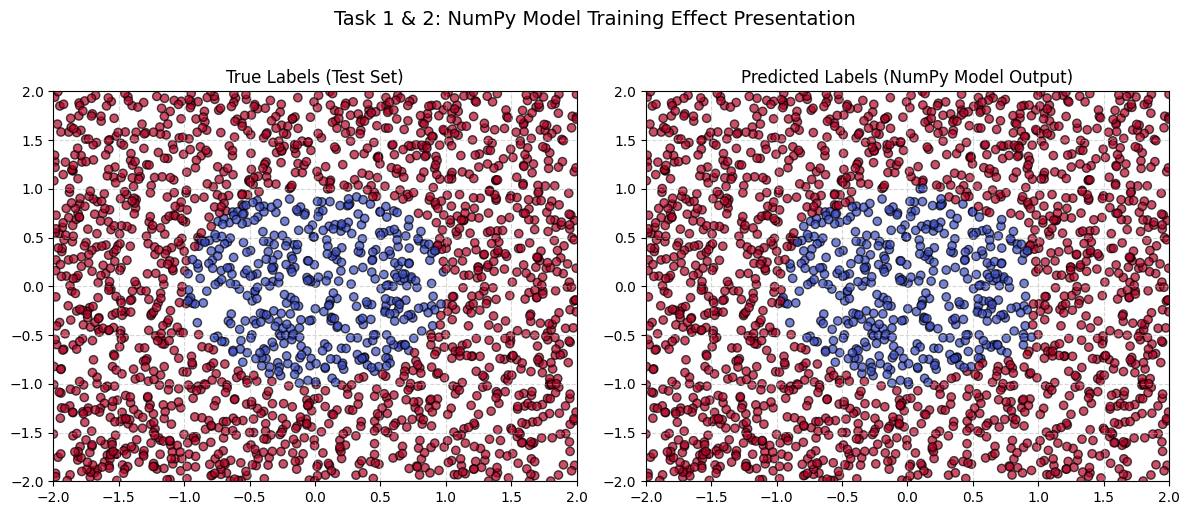

In [6]:
# ==================== 7. 纯 NumPy 版：展现训练完成的模型效果 ====================
import matplotlib.pyplot as plt

# 1. 使用训练好的权重对测试集 (X_test) 进行一次完整的前向传播
test_z1 = np.dot(X_test, W1) + b1
test_a1 = relu(test_z1)

test_z2 = np.dot(test_a1, W2) + b2
test_a2 = relu(test_z2)

# 得到未归一化的输出得分 (Logits)
test_logits = np.dot(test_a2, W3) + b3

# 2. 通过 argmax 提取出模型预测的最终类别 (0 或 1)
# 对应 PyTorch 的 torch.argmax(outputs, dim=1)
y_pred = np.argmax(test_logits, axis=1)

# 3. 核心转换：按照 utils 中 plot_data 的格式要求，将特征与标签横向拼接成 [x, y, tag]
# data_true 拼接真实标签，data_pred 拼接预测标签
data_true = np.hstack([X_test, y_test.reshape(-1, 1)])
data_pred = np.hstack([X_test, y_pred.reshape(-1, 1)])

# 4. 绘图实现：左右双子图直观对比
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 左图：测试集的真实标签分布
ax[0].scatter(data_true[:, 0], data_true[:, 1], c=data_true[:, 2], cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.7)
ax[0].set_title("True Labels (Test Set)")
ax[0].set_xlim(-2, 2)
ax[0].set_ylim(-2, 2)
ax[0].grid(True, linestyle='--', alpha=0.5)

# 右图：你手搓的 NumPy 模型对测试集的预测分布
ax[1].scatter(data_pred[:, 0], data_pred[:, 1], c=data_pred[:, 2], cmap=plt.cm.coolwarm, edgecolors='k', alpha=0.7)
ax[1].set_title("Predicted Labels (NumPy Model Output)")
ax[1].set_xlim(-2, 2)
ax[1].set_ylim(-2, 2)
ax[1].grid(True, linestyle='--', alpha=0.5)

# 总大标题
plt.suptitle("Task 1 & 2: NumPy Model Training Effect Presentation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# 1. 将你生成的 Numpy 数据转换为 PyTorch 的张量 (Tensor)
X = torch.FloatTensor(raw_data[:, :2]) # 提取前两列坐标点
y = torch.LongTensor(raw_data[:, 2])   # 提取最后一列标签

# 2. 划分 8:2 的训练集与测试集
full_dataset = TensorDataset(X, y) #将特征和标签组合成完整数据集
train_size = int(0.8 * len(full_dataset)) #计算训练集大小
test_size = len(full_dataset) - train_size #计算测试集大小
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size]) #train_dataset和test_dataset分别是训练集和测试集的子集对象，random_split会根据指定的大小划分数据。

# 3. 放入 PyTorch 数据加载器 (DataLoader)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) #Dataloader是数据加载器，参1是训练集，2是批量大小，3是是否打乱
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False) #测试集不打乱

# 4. 定义模型架构
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.net = nn.Sequential( #这行是定义一个顺序容器
            nn.Linear(2, 4), #2是特征数量，4是神经元数量
            nn.ReLU(), #激活函数
            nn.Linear(4, 4), #前一个
            nn.ReLU(),
            nn.Linear(4, 2)
        )
        for m in self.net.modules(): #对网络中的每一层遍历
            if isinstance(m, nn.Linear): #如果是线性层，就进行Kaiming初始化，这种初始化是通过调整权重方差来适应ReLU的特性
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu') #这行是针对线性层的权重进行初始化，使得权重的方差为2/n,其中n是输入特征的数量
                nn.init.constant_(m.bias, 0.0) #初始化偏置为0.0
                
    def forward(self, x): #前向传播函数
        return self.net(x)

# 5. 实例化模型与优化器
device = torch.device("cuda" if torch.cuda.is_available() else "cpu") #检查是否有可用的GPU
model = MLP().to(device) #如果GPU可用就移动
criterion = nn.CrossEntropyLoss() #这是BCE损失函数
optimizer = optim.SGD(model.parameters(), lr=0.1) #优化器是随机梯度下降
#有个问题，使用优化器是因为分了batch

# 6. 开始循环迭代训练
EPOCHS = 100
print(f"正在基于你生成的数据进行 PyTorch 训练...")
for epoch in range(EPOCHS):
    model.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
    # 每 100 轮打印一次训练集准确率
    if (epoch + 1) % 10 == 0 or epoch == 0:
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for batch_X, batch_y in train_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                preds = torch.argmax(outputs, dim=1)
                correct += (preds == batch_y).sum().item()
                total += batch_y.size(0)
        print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {loss.item():.4f} | Train Acc: {(correct/total)*100:.2f}%")

print("模型训练完成！")

正在基于你生成的数据进行 PyTorch 训练...
Epoch [1/100] | Train Loss: 0.3701 | Train Acc: 80.20%
Epoch [10/100] | Train Loss: 0.0589 | Train Acc: 97.60%
Epoch [20/100] | Train Loss: 0.0390 | Train Acc: 98.54%
Epoch [30/100] | Train Loss: 0.0442 | Train Acc: 98.94%
Epoch [40/100] | Train Loss: 0.0203 | Train Acc: 98.94%
Epoch [50/100] | Train Loss: 0.0041 | Train Acc: 99.00%
Epoch [60/100] | Train Loss: 0.0658 | Train Acc: 99.06%
Epoch [70/100] | Train Loss: 0.0312 | Train Acc: 99.05%
Epoch [80/100] | Train Loss: 0.0020 | Train Acc: 99.24%
Epoch [90/100] | Train Loss: 0.0318 | Train Acc: 99.25%
Epoch [100/100] | Train Loss: 0.0157 | Train Acc: 98.88%
模型训练完成！


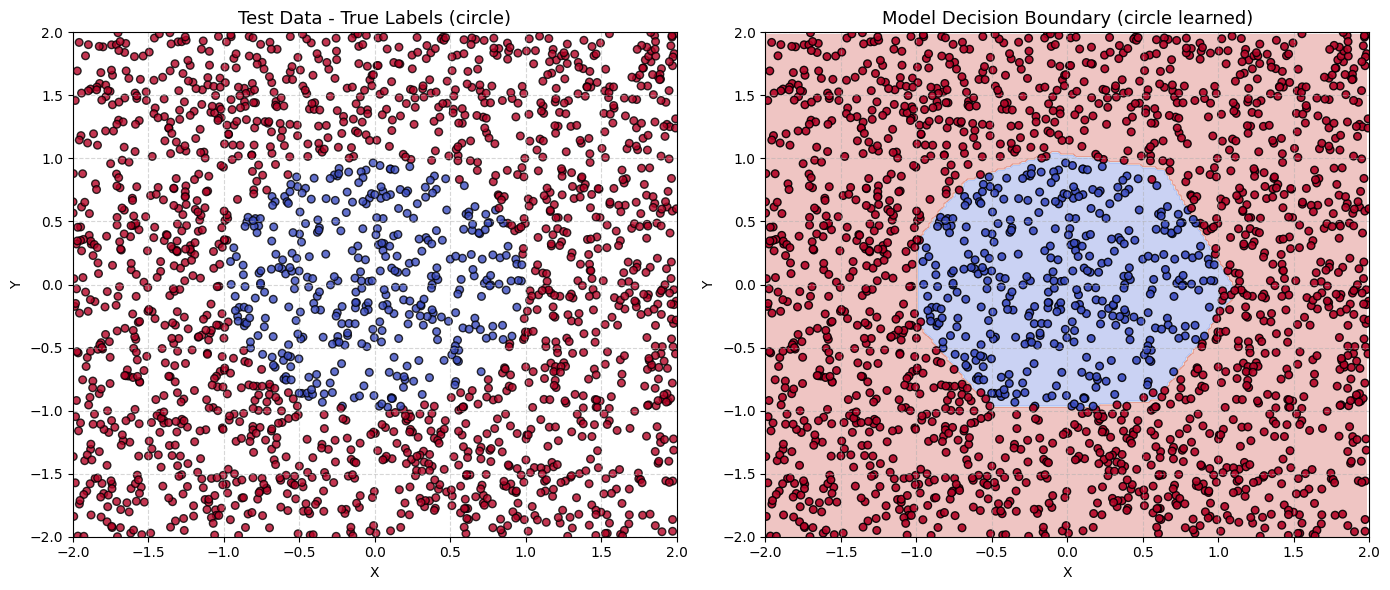

In [ ]:
# ==================== 7. 绘制图像说明训练效果 ====================
import numpy as np
import matplotlib.pyplot as plt
import torch

# 【防错检查 1】：检查你的模型变量名是否正确
if 'model' not in locals() and 'model' not in globals():
    raise NameError("❌ 未检测到 'model' 变量！请确保你已经运行了【定义并实例化模型】以及【模型训练】的单元格。")

# 【防错检查 2】：自动配置设备
if 'device' not in locals() and 'device' not in globals():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 📍 这里的名称可以手动改为你当前训练的形状 ("circle"、"triangle" 或 "square")
CURRENT_MODE = "circle"  

# 将模型切换为评估模式（关闭 Dropout / BatchNorm 等）
model.eval()

# 1. 【智能兼容提取】：自动识别并兼容 Subset 或 TensorDataset 提取测试集数据
try:
    if hasattr(test_dataset, 'dataset'):
        # 如果是 random_split 划分出来的 Subset 对象
        X_test = test_dataset.dataset.tensors[0][test_dataset.indices].numpy()
        y_test = test_dataset.dataset.tensors[1][test_dataset.indices].numpy()
    else:
        # 如果是独立的 TensorDataset 对象
        X_test = test_dataset.tensors[0].numpy()
        y_test = test_dataset.tensors[1].numpy()
except NameError:
    raise NameError("❌ 未检测到 'test_dataset' 变量！请确保你运行了【划分数据集/定义测试集】的单元格。")


# 2. 生成密集的覆盖网格点 [-2, 2]，用于绘制背景的颜色边界
x_min, x_max = -2.0, 2.0
y_min, y_max = -2.0, 2.0
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xx.ravel(), yy.ravel()]

# 将网格点转换为 Tensor 并送入对应设备
grid_tensor = torch.FloatTensor(grid_points).to(device)


# 3. 让训练好的模型预测这 40000 个网格点的分类（用于画出分界线）
with torch.no_grad():
    outputs = model(grid_tensor)
    # 对应方案 B (双输出 logits)：使用 argmax 提取出概率最大的类别索引 (0 或 1)
    preds = torch.argmax(outputs, dim=1).cpu().numpy()

# 将预测结果还原为二维网格形状
preds = preds.reshape(xx.shape)


# 4. 开始绘制对比图
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# ---- 左图：测试集的真实标签 ----
scatter0 = ax[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', s=30, alpha=0.8)
ax[0].set_title(f"Test Data - True Labels ({CURRENT_MODE})", fontsize=13)
ax[0].set_xlabel("X")
ax[0].set_ylabel("Y")
ax[0].set_xlim(-2, 2)
ax[0].set_ylim(-2, 2)
ax[0].grid(True, linestyle='--', alpha=0.5)

# ---- 右图：模型学到的决策边界 + 测试集散点 ----
# contourf 用淡红、淡蓝色渲染出模型的“势力范围”（决策边界）
ax[1].contourf(xx, yy, preds, alpha=0.3, cmap=plt.cm.coolwarm)
scatter1 = ax[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=plt.cm.coolwarm, edgecolors='k', s=30, alpha=0.9)
ax[1].set_title(f"Model Decision Boundary ({CURRENT_MODE} learned)", fontsize=13)
ax[1].set_xlabel("X")
ax[1].set_ylabel("Y")
ax[1].set_xlim(-2, 2)
ax[1].set_ylim(-2, 2)
ax[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()